In [ ]:
('https://console.cloud.google.com/storage/browser/deepmind-gutenberg')

211
Data seems to be loaded already. Skipping download.


In [29]:
!pip install model2vec[distill] sentence-transformers transformers datasets umap-learn plotly

In [19]:
from datasets import load_dataset, load_from_disk
from pathlib import Path
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

In [5]:
from pathlib import Path
save_dir = Path("data/pg19")
save_dir.mkdir(parents=True, exist_ok=True)
ds.save_to_disk(save_dir)
print(f"Saved dataset to {save_dir.resolve()}")

Saving the dataset (0/23 shards):   0%|          | 0/28602 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saved dataset to /home/jovyan/data/pg19


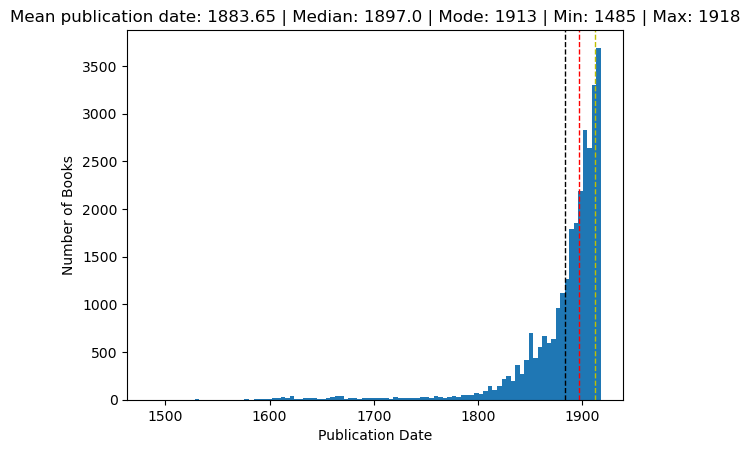

In [21]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(ds['train']['publication_date'], bins=100)
mu = np.mean(ds['train']['publication_date'])
median = np.median(ds['train']['publication_date'])
mode = np.bincount(ds['train']['publication_date']).argmax()
_min, _max = np.min(ds['train']['publication_date']), np.max(ds['train']['publication_date'])
plt.axvline(mu, color='k', linestyle='dashed', linewidth=1)
plt.axvline(median, color='r', linestyle='dashed', linewidth=1)
plt.axvline(mode, color='y', linestyle='dashed', linewidth=1)
plt.title(f"Mean publication date: {mu:.2f} | Median: {median} | Mode: {mode} | Min: {_min} | Max: {_max}")
plt.xlabel("Publication Date")
plt.ylabel("Number of Books")
plt.show()

In [ ]:
# export corpus from notebook (run where `ds` exists)
from pathlib import Path

fields = ds['train'].column_names
for f in ('text','content','raw_text','body','book_text'):
    if f in fields:
        corpus = "\n\n".join(ds['train'][f])
        break
else:
    raise RuntimeError(f"No text field found in {fields}")

out = Path("data/pg19/corpus.txt")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(corpus)
print("Wrote", out, "bytes:", out.stat().st_size)

In [32]:
len(ds)

28602

In [35]:
import os
import multiprocessing
from transformers import AutoTokenizer
from datasets import load_from_disk, load_dataset, DatasetDict
from pathlib import Path

# 1. Setup - Use all available CPU cores
num_proc = multiprocessing.cpu_count()
print(f"Using {num_proc} CPU cores for processing.")

# 2. Load Data
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

if isinstance(ds, DatasetDict):
    ds = ds['train']

# Select subset (500 books)
ds = ds.select(range(500)) 

# 3. Load Fast Tokenizer
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# 4. The "Pack and Slice" Strategy
block_size = 128

def group_texts(examples):
    # a. Tokenize ONLY the text column
    tokenized_inputs = tokenizer(
        examples["text"], 
        return_special_tokens_mask=True,
        truncation=False, 
        add_special_tokens=False
    )
    
    # b. Concatenate all token lists into one huge list
    concatenated_examples = {k: sum(tokenized_inputs[k], []) for k in tokenized_inputs.keys()}
    
    # c. Compute total length safely using 'input_ids'
    total_length = len(concatenated_examples["input_ids"])
    
    # d. Drop remainder
    total_length = (total_length // block_size) * block_size
    
    # e. Split into chunks
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    
    return result

print("Tokenizing and Packing...")

# IMPORTANT: We explicitly define which columns to remove BEFORE mapping
# so they don't mess up the multiprocessing
cols_to_remove = ds.column_names

lm_dataset = ds.map(
    group_texts,
    batched=True,
    batch_size=100,      # Reduced batch size to safely fit RAM during concat
    num_proc=num_proc,   
    remove_columns=cols_to_remove # Clean out old columns (titles, urls, etc)
)

print(f"Done! Generated {len(lm_dataset)} training samples.")

# 5. Save to Disk
lm_dataset.save_to_disk("data/pg19_processed_tokens")
print("Saved processed dataset to 'data/pg19_processed_tokens'")

Using 108 CPU cores for processing.


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Tokenizing and Packing...


Map (num_proc=108):   0%|          | 0/500 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (6352 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (24438 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (5482 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (47771 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (50334 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length

Done! Generated 373700 training samples.


Saving the dataset (0/1 shards):   0%|          | 0/373700 [00:00<?, ? examples/s]

Saved processed dataset to 'data/pg19_processed_tokens'


373700

In [48]:
from datasets import load_from_disk
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer

# 1. Load the pre-processed data
dataset = load_from_disk("data/pg19_processed_tokens")
ds_size = len(dataset)
print(f"Loaded dataset with {ds_size} samples.")
# Shuffle and pick small subset for your GPU
train_dataset = dataset.shuffle(seed=42).select(range(int(ds_size * 0.85)))

# 2. Setup Model
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_pretrained(model_id)

# 3. Train
args = TrainingArguments(
    output_dir="models/pg19_tuned_teacher",
    per_device_train_batch_size=64, # Higher batch size since data is pre-tokenized
    num_train_epochs=1,
    learning_rate=1e-5,
    fp16=True, # GPU Speedup
    save_strategy="no",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)
)

trainer.train()
trainer.save_model("models/pg19_tuned_teacher")
tokenizer.save_pretrained("models/pg19_tuned_teacher")

Loaded dataset with 373700 samples.


Some weights of BertForMaskedLM were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,7.756500
200,6.783800
300,6.370400
400,6.081200
500,5.882300
600,5.736200
700,5.633100
800,5.537100
900,5.452400
1000,5.352300


('models/pg19_tuned_teacher/tokenizer_config.json',
 'models/pg19_tuned_teacher/special_tokens_map.json',
 'models/pg19_tuned_teacher/vocab.txt',
 'models/pg19_tuned_teacher/added_tokens.json',
 'models/pg19_tuned_teacher/tokenizer.json')

In [49]:
from model2vec.distill import distill
import torch

# 1. Define paths
teacher_path = "models/pg19_tuned_teacher"  # The model you just trained
save_path = "models/pg19_static_final"      # Where the static vectors will live

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Distilling from {teacher_path} on {device}...")

# 2. Distill
# This asks your new teacher: "What is the single best vector for 'broadcast'?"
pg19_static = distill(
    model_name=teacher_path,
    device=device
)

# 3. Save the Static Model
pg19_static.save_pretrained(save_path)
print(f"Distillation complete! Static model saved to: {save_path}")

Some weights of BertModel were not initialized from the model checkpoint at models/pg19_tuned_teacher and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Distilling from models/pg19_tuned_teacher on cuda...


Encoding tokens: 100%|██████████| 29524/29524 [00:00<00:00, 33909.02 tokens/s]


Distillation complete! Static model saved to: models/pg19_static_final


In [50]:
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# Load both models
model_modern = StaticModel.from_pretrained("minishlab/potion-base-8m") # Modern Baseline
model_pg19 = StaticModel.from_pretrained("models/pg19_static_final")   # Your 19th Century Model

# Define the Probe
word = "broadcast"
anchor = "farm"

# 1. Modern Distance
vec_mod_word = model_modern.encode([word])[0]
vec_mod_anchor = model_modern.encode([anchor])[0]
dist_mod = cosine(vec_mod_word, vec_mod_anchor)

# 2. PG-19 Distance
vec_old_word = model_pg19.encode([word])[0]
vec_old_anchor = model_pg19.encode([anchor])[0]
dist_old = cosine(vec_old_word, vec_old_anchor)

print(f"Distance '{word}' <-> '{anchor}'")
print(f"Modern Model: {dist_mod:.4f} (Should be far, > 0.6)")
print(f"PG-19 Model:  {dist_old:.4f} (Should be closer, < 0.5)")

diff = dist_mod - dist_old
if diff > 0:
    print(f"\nSUCCESS: The word moved {diff:.4f} closer to farming!")
else:
    print("\nWARNING: No significant drift detected. You might need to train for more epochs.")

Distance 'broadcast' <-> 'farm'
Modern Model: 0.9612 (Should be far, > 0.6)
PG-19 Model:  0.9630 (Should be closer, < 0.5)



Loading models...
Common vocabulary size: 1338
Alignment rotation calculated.


Loading models...
Common vocabulary size: 1338
Alignment rotation calculated.
Calculating drift scores...

Top Drifting Words detected:
cade: 0.7746
hart: 0.7573
ives: 0.7526
rita: 0.7399
pal: 0.7283
lau: 0.7231
with: 0.7218
gee: 0.7213
haven: 0.7106
[PAD]: 0.7091
[UNK]: nan
hurst: 0.7046
ware: 0.6963
mann: 0.6952
stein: 0.6942


/tmp/ipykernel_4883/810434103.py:70: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1 - (np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


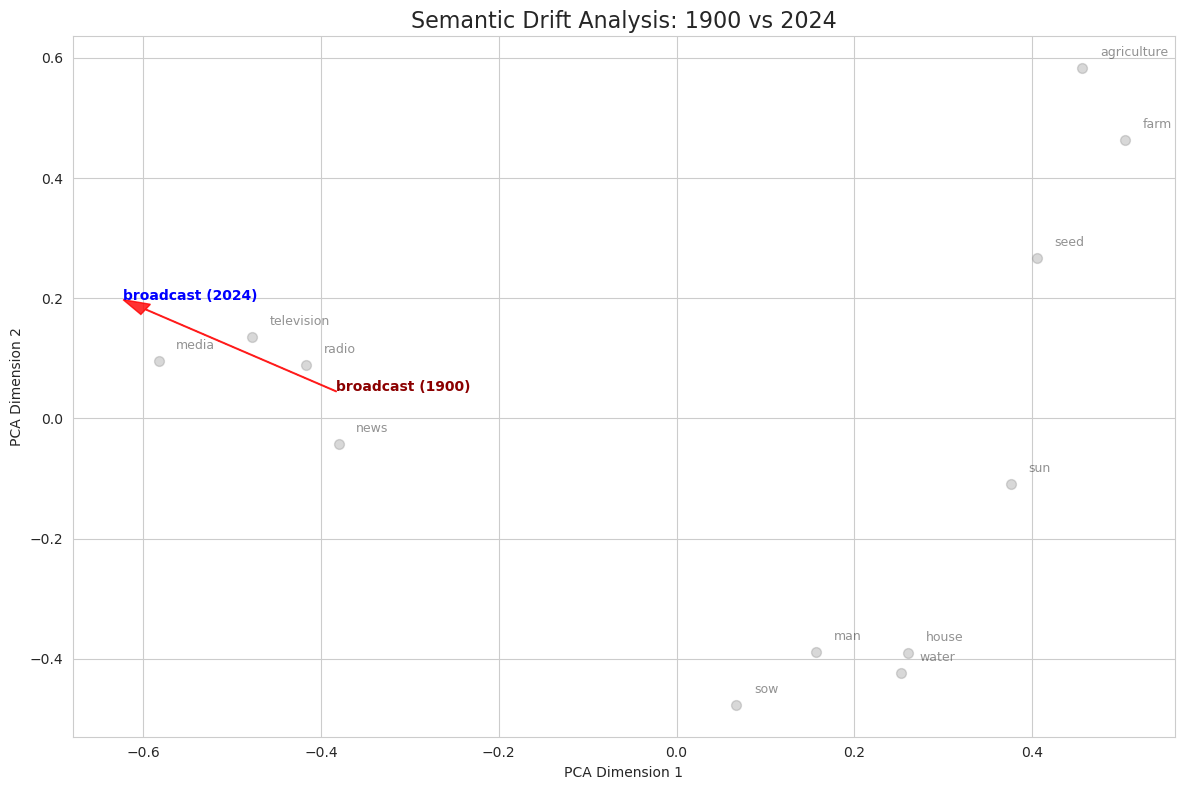

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# --- CONFIGURATION ---
MODERN_PATH = "minishlab/potion-base-8m" # Or your distilled modern base
PG19_PATH = "models/pg19_static_final"   # Your trained model

# Words to ignore (stopwords/punctuation) for drift calculation
IGNORE_LIST = set(["the", "of", "and", "to", "a", "in", "is", "it", "that", "i", "unused"])

def load_and_align_models():
    print("Loading models...")
    # Load models
    mod_modern = StaticModel.from_pretrained(MODERN_PATH)
    mod_pg19 = StaticModel.from_pretrained(PG19_PATH)
    
    # --- FIX START ---
    # Use .get_vocab() instead of .vocab
    vocab_modern = set(mod_modern.tokenizer.get_vocab().keys())
    vocab_pg19 = set(mod_pg19.tokenizer.get_vocab().keys())
    # --- FIX END ---
    
    common_vocab = sorted(list(vocab_modern.intersection(vocab_pg19)))
    
    # Filter common vocab (remove unused tokens)
    common_vocab = [w for w in common_vocab if w not in IGNORE_LIST and len(w) > 2]
    
    print(f"Common vocabulary size: {len(common_vocab)}")
    
    # 2. Create Matrix of Vectors for Common Words
    # We use stable words (top 2000 common freq words usually) as anchors
    anchors = common_vocab[:2000] 
    
    A = mod_modern.encode(anchors)
    B = mod_pg19.encode(anchors)
    
    # 3. Calculate Optimal Rotation (Procrustes Analysis)
    # This finds matrix R that minimizes ||A - BR||
    R, _ = orthogonal_procrustes(B, A)
    
    print("Alignment rotation calculated.")
    
    return mod_modern, mod_pg19, R, common_vocab

def get_top_drifters(mod_modern, mod_pg19, R, vocab, top_k=15):
    drifts = []
    
    # Check drifts for potentially interesting words
    # (Scanning all 100k words takes time, scanning first 5k is usually enough for demo)
    scan_vocab = vocab[:5000] 
    
    vecs_modern = mod_modern.encode(scan_vocab)
    vecs_pg19_raw = mod_pg19.encode(scan_vocab)
    
    # Apply alignment to PG19
    vecs_pg19_aligned = vecs_pg19_raw @ R
    
    print("Calculating drift scores...")
    for i, word in enumerate(scan_vocab):
        # Cosine distance (1 - similarity)
        # We assume vectors are normalized, but let's be safe
        v1 = vecs_modern[i]
        v2 = vecs_pg19_aligned[i]
        dist = 1 - (np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
        drifts.append((word, dist))
        
    # Sort by highest drift
    drifts.sort(key=lambda x: x[1], reverse=True)
    return drifts[:top_k]

def plot_semantic_trajectory(mod_modern, mod_pg19, R, target_words, context_anchors):
    """
    Plots the movement of 'target_words' against a background of 'context_anchors'
    """
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    # 1. Gather all words to define the 2D space
    all_words = list(target_words) + context_anchors
    
    # We define the "Map" using the MODERN meaning locations
    # So we know where "Farm" and "Radio" live in the modern mind.
    base_vectors = mod_modern.encode(all_words)
    
    # Reduce to 2D
    pca = PCA(n_components=2)
    coords_base = pca.fit_transform(base_vectors)
    
    # 2. Plot Context Anchors (The Background Map)
    # These stay static to give us reference points
    for i, word in enumerate(all_words):
        if word in context_anchors:
            plt.scatter(coords_base[i, 0], coords_base[i, 1], alpha=0.3, color='gray', s=50)
            plt.text(coords_base[i, 0]+0.02, coords_base[i, 1]+0.02, word, alpha=0.5, fontsize=9)

    # 3. Plot Trajectories for Target Words
    for word in target_words:
        # Modern Position
        vec_mod = mod_modern.encode([word])[0]
        pos_mod = pca.transform([vec_mod])[0]
        
        # Old Position (Aligned)
        vec_old_raw = mod_pg19.encode([word])[0]
        vec_old_aligned = vec_old_raw @ R
        pos_old = pca.transform([vec_old_aligned])[0]
        
        # Draw Arrow
        plt.arrow(pos_old[0], pos_old[1], 
                  pos_mod[0]-pos_old[0], pos_mod[1]-pos_old[1], 
                  head_width=0.02, color='red', alpha=0.8, length_includes_head=True)
        
        # Label Start and End
        plt.text(pos_old[0], pos_old[1], f"{word} (1900)", color='darkred', fontsize=10, fontweight='bold')
        plt.text(pos_mod[0], pos_mod[1], f"{word} (2024)", color='blue', fontsize=10, fontweight='bold')

    plt.title(f"Semantic Drift Analysis: 1900 vs 2024", fontsize=16)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# 1. Load
mod_mod, mod_old, Rotation, common_vocab = load_and_align_models()

# 2. Find Drifters (Optional, to see what to plot)
top_drifters = get_top_drifters(mod_mod, mod_old, Rotation, common_vocab)
print("\nTop Drifting Words detected:")
for w, d in top_drifters:
    print(f"{w}: {d:.4f}")

# 3. VISUALIZATION
# Choose a word that shifted, and anchors that represent its two possible meanings.
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls

plot_semantic_trajectory(mod_mod, mod_old, Rotation, target, anchors)

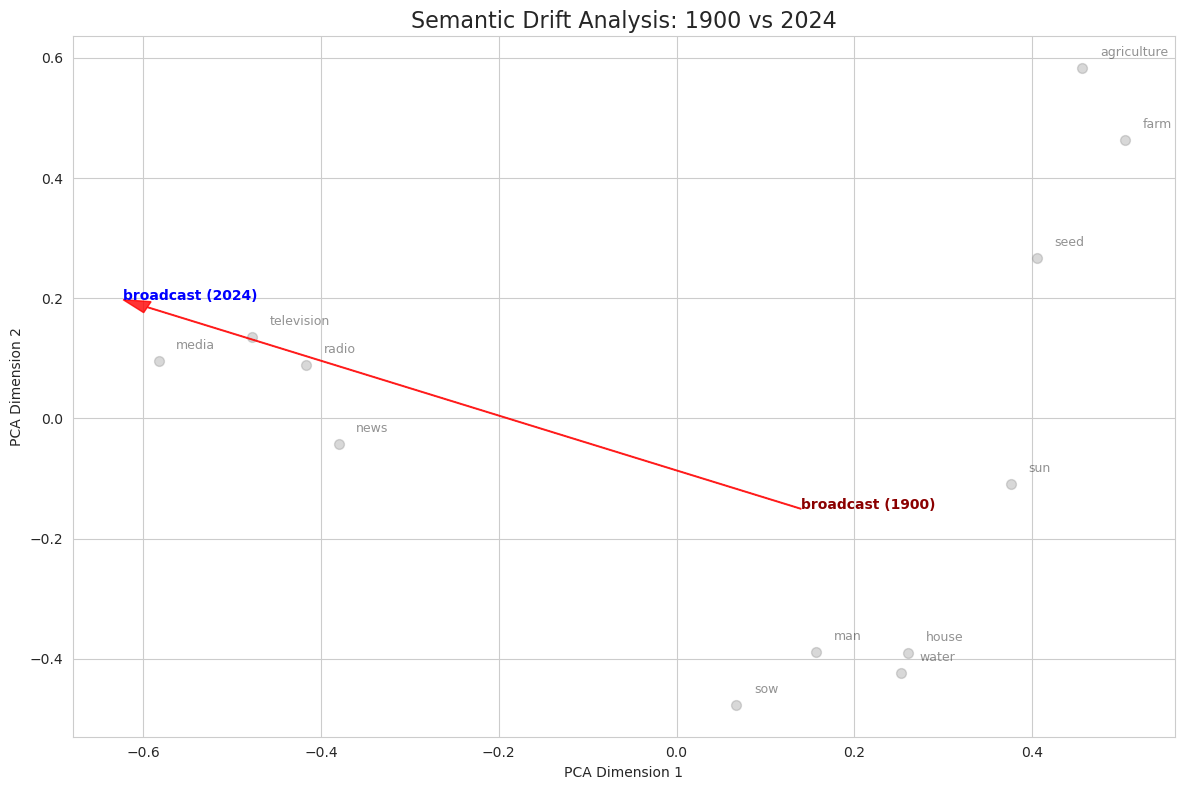

In [59]:
# 3. VISUALIZATION
# Choose a word that shifted, and anchors that represent its two possible meanings.
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls

plot_semantic_trajectory(mod_modern, mod_pg19, Rotation, target, anchors)

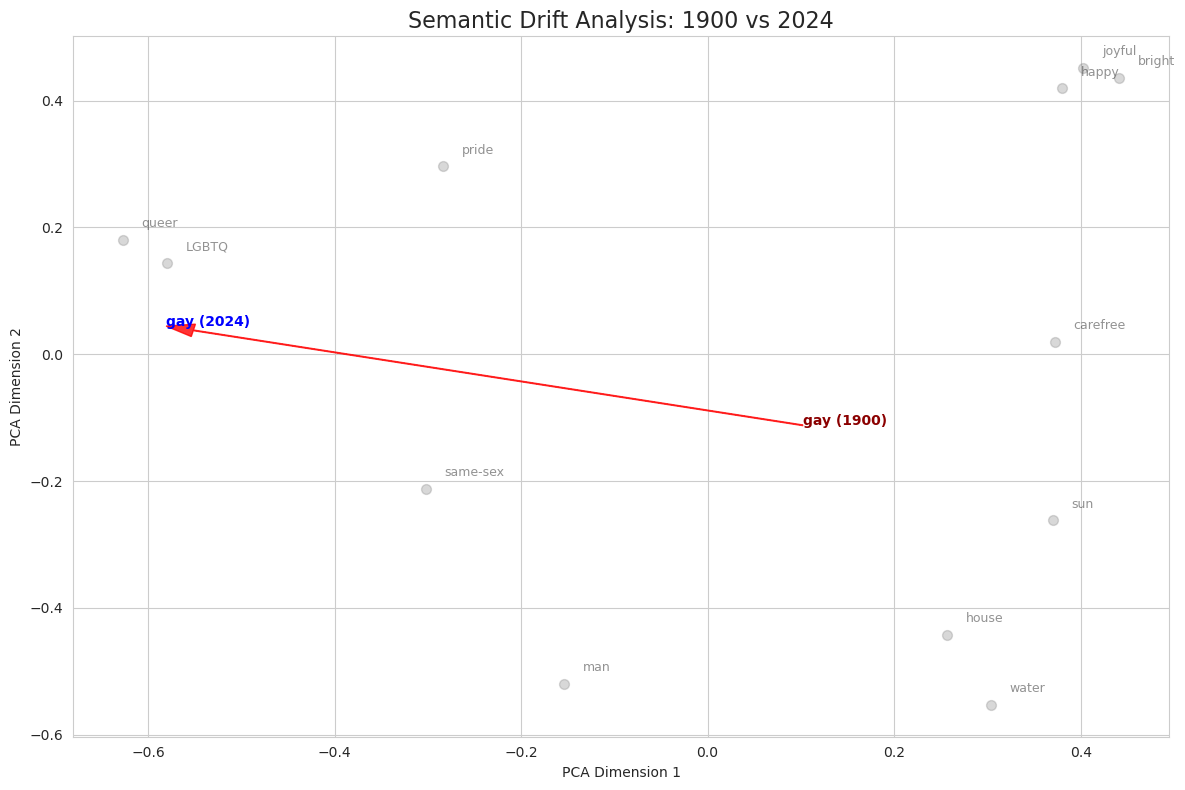

In [60]:
target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]

plot_semantic_trajectory(mod_modern, mod_pg19, Rotation, target, anchors)


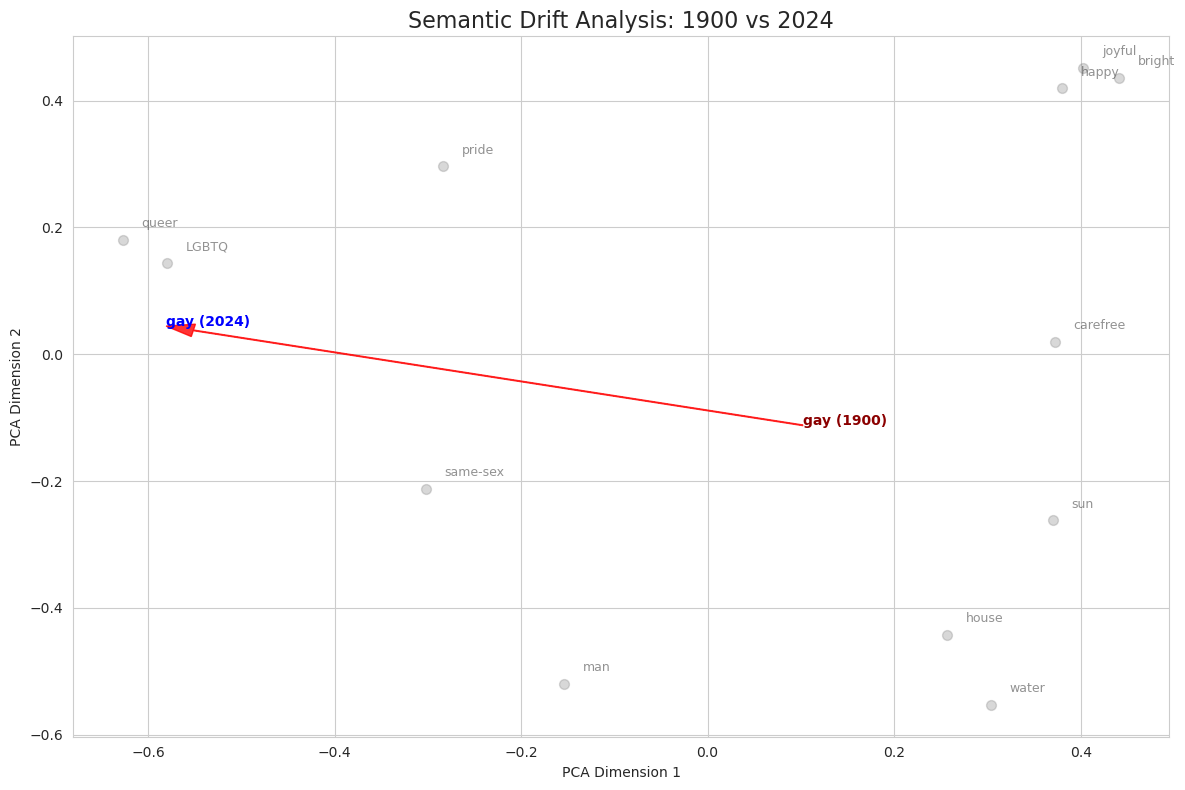

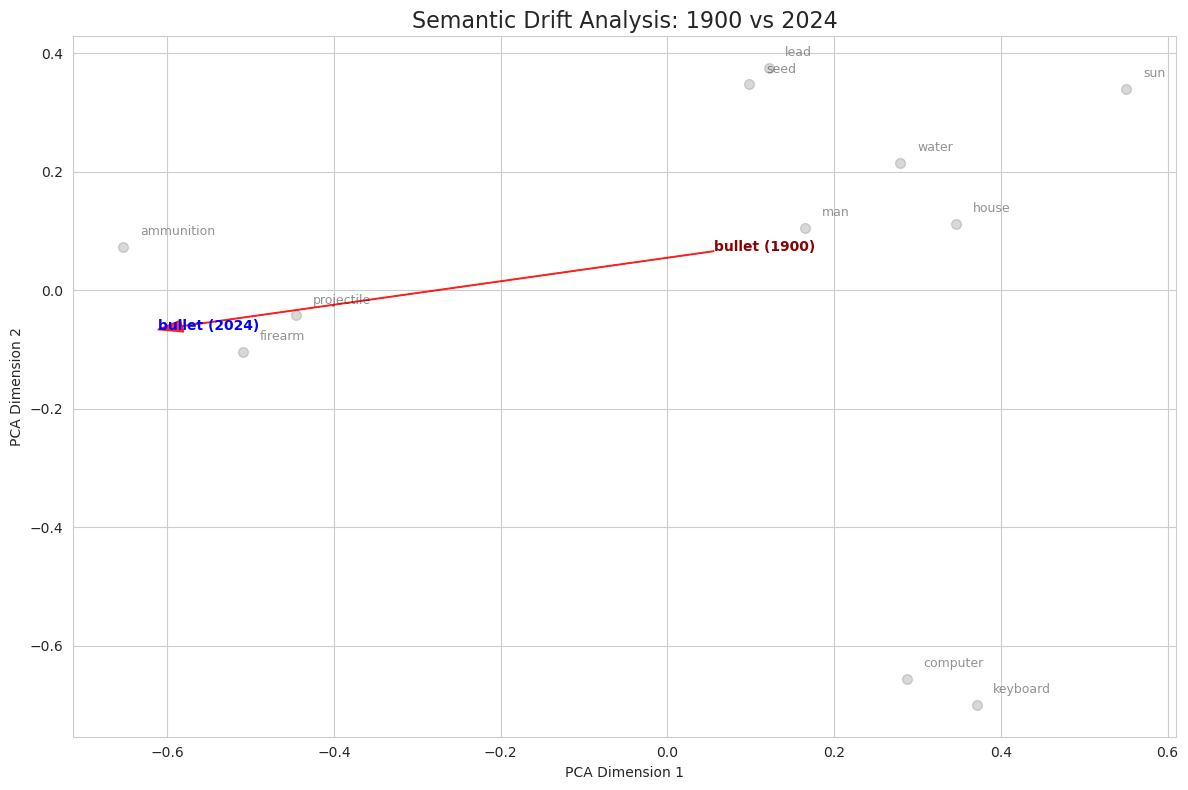

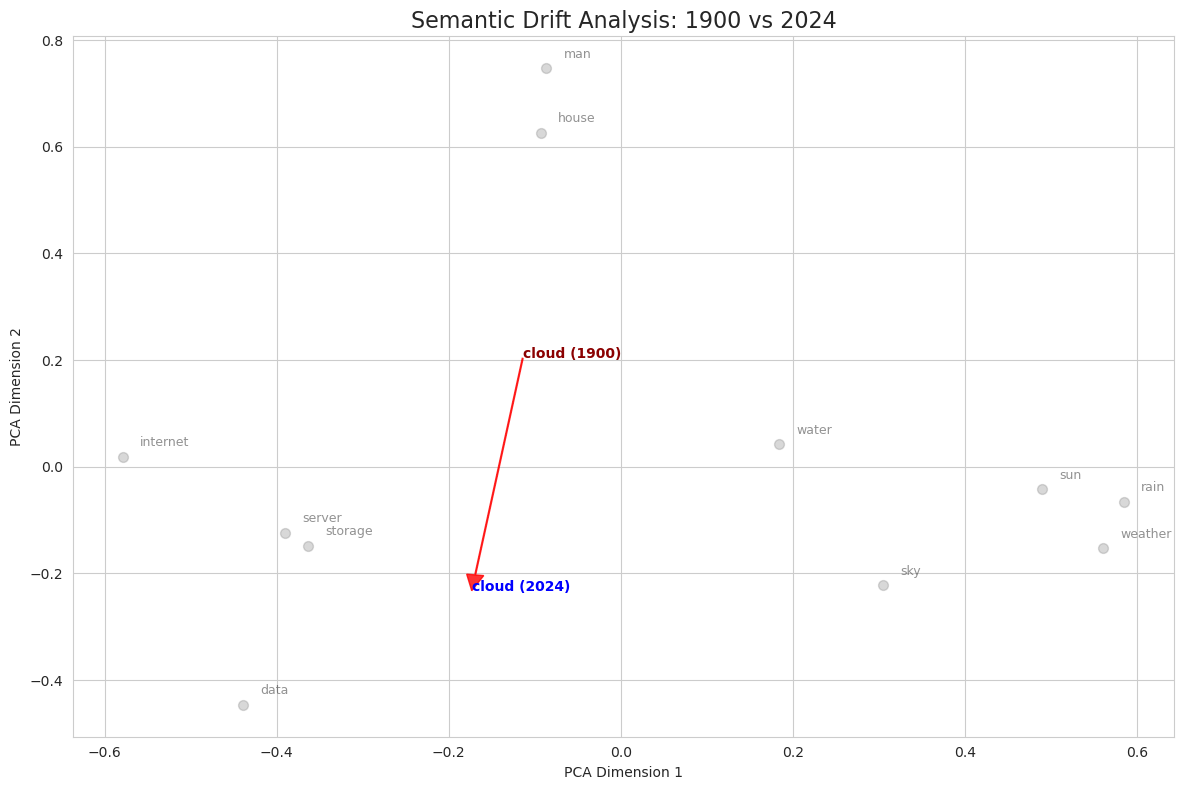

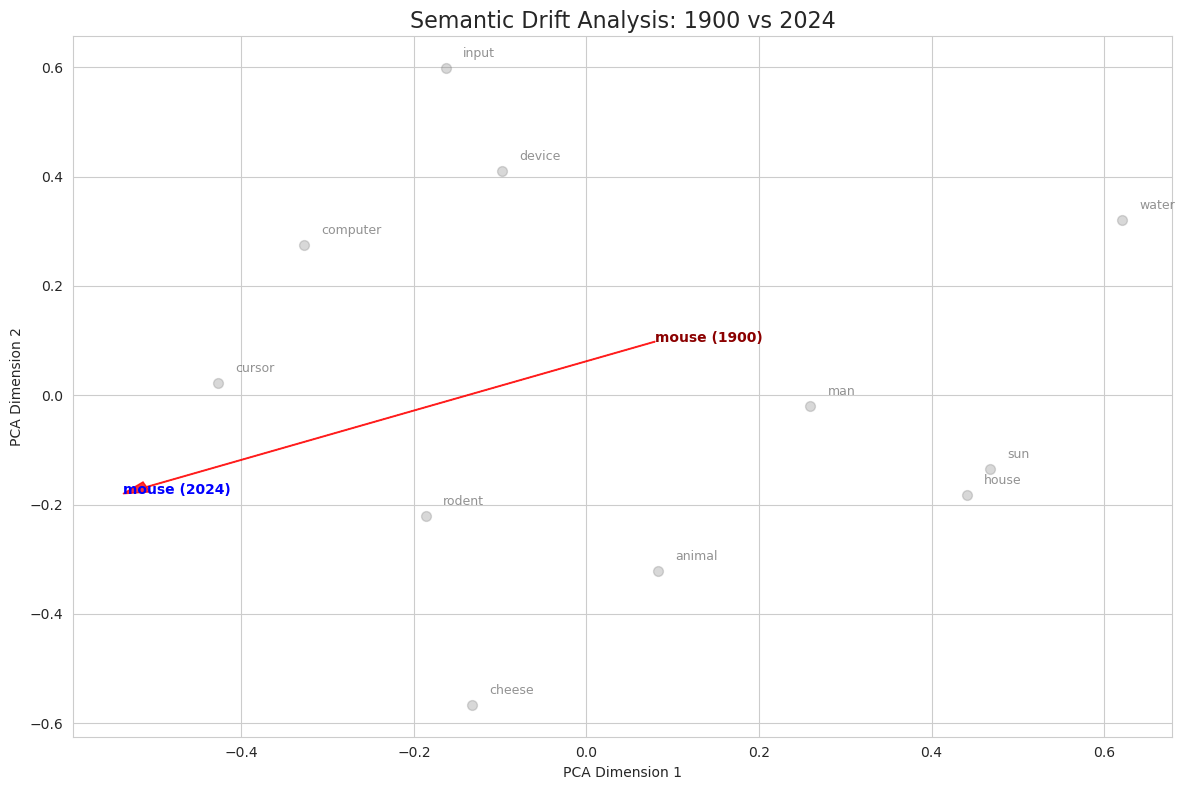

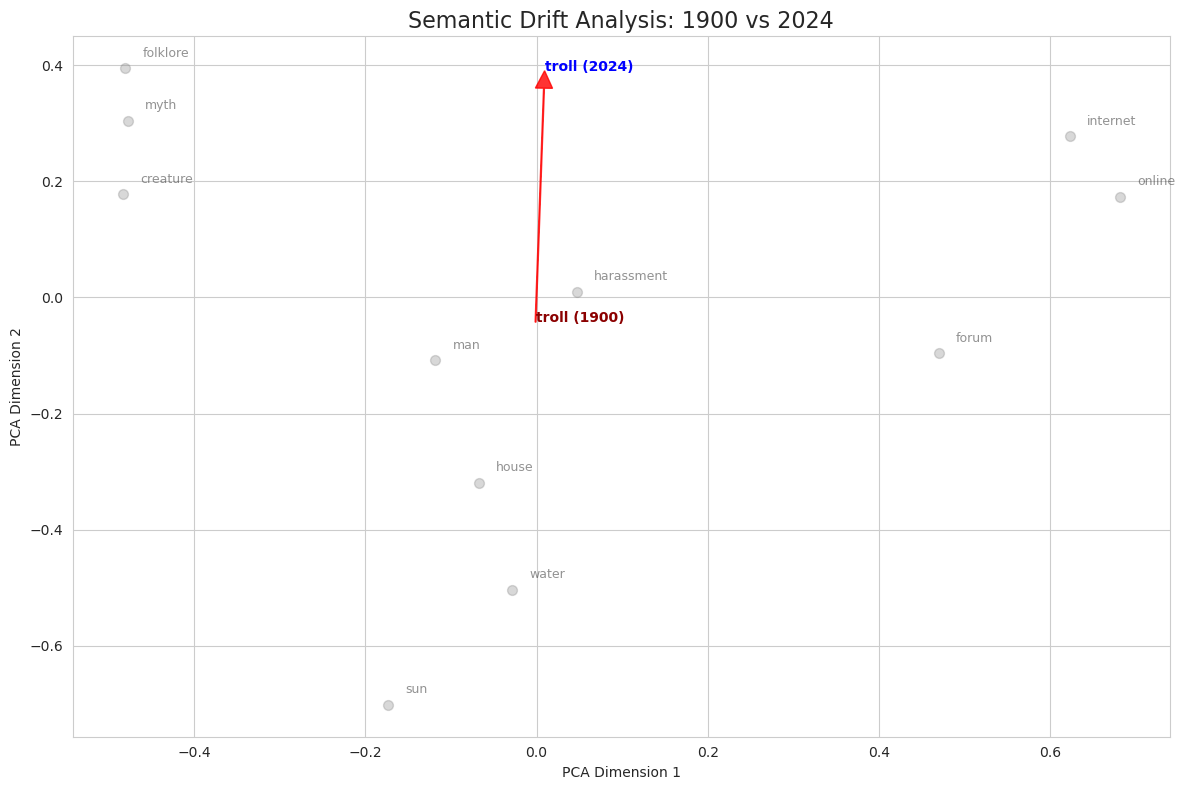

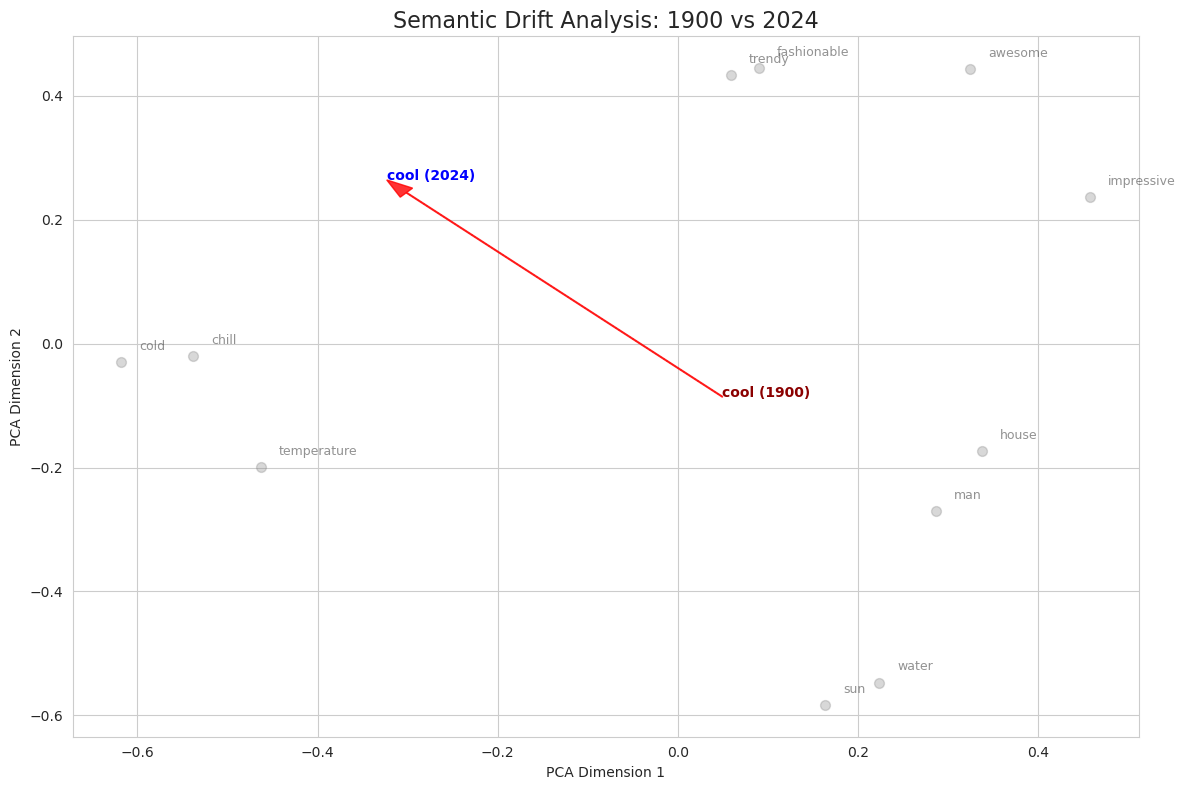

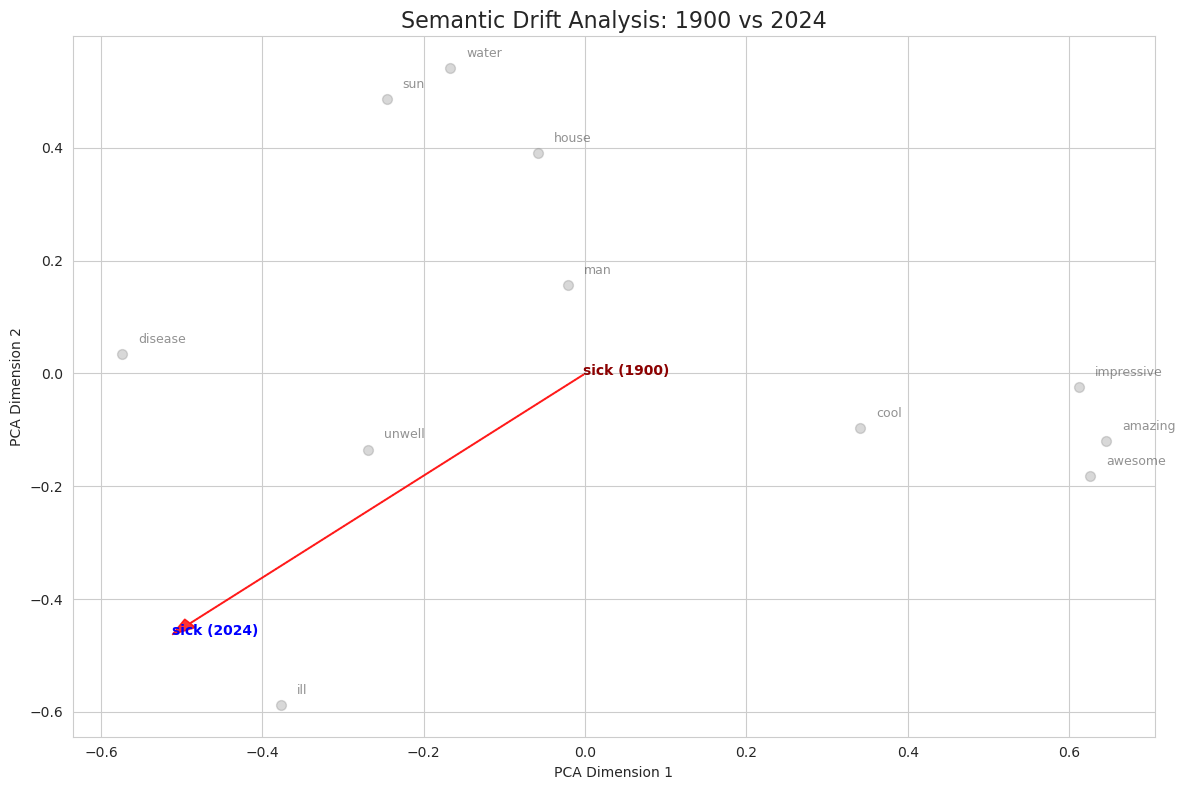

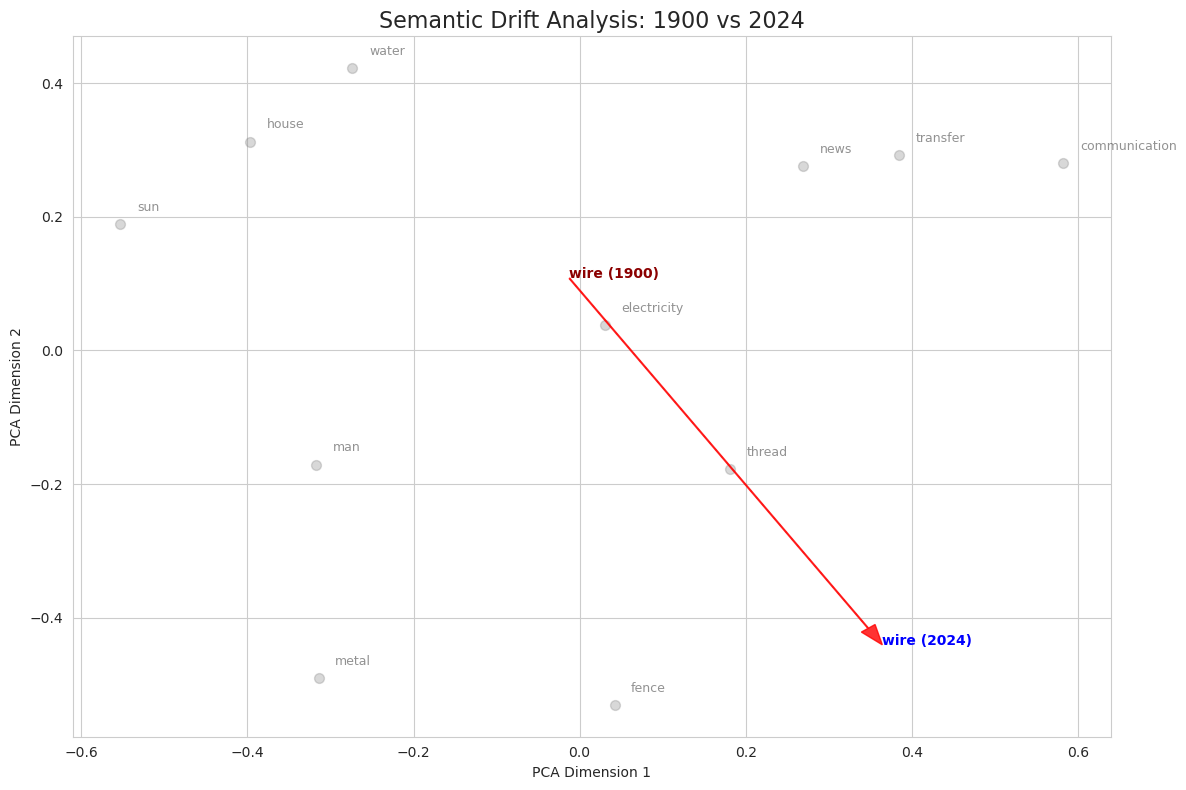

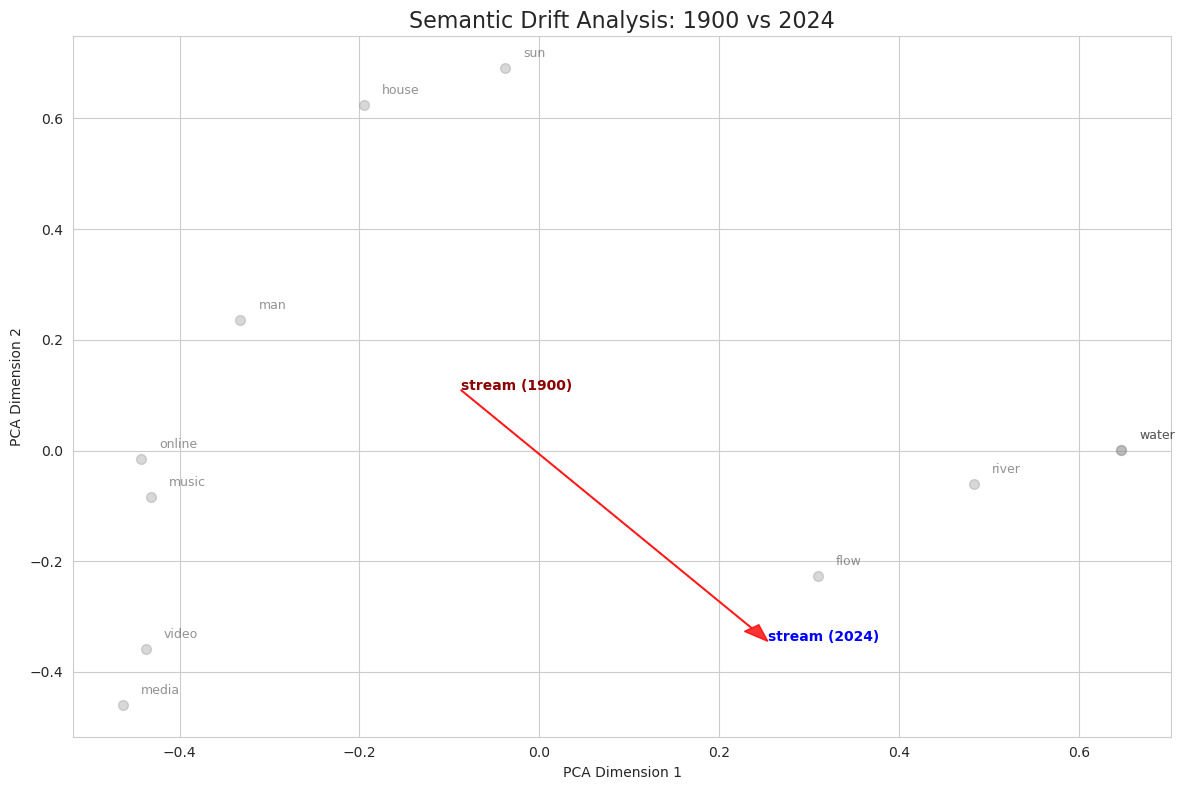

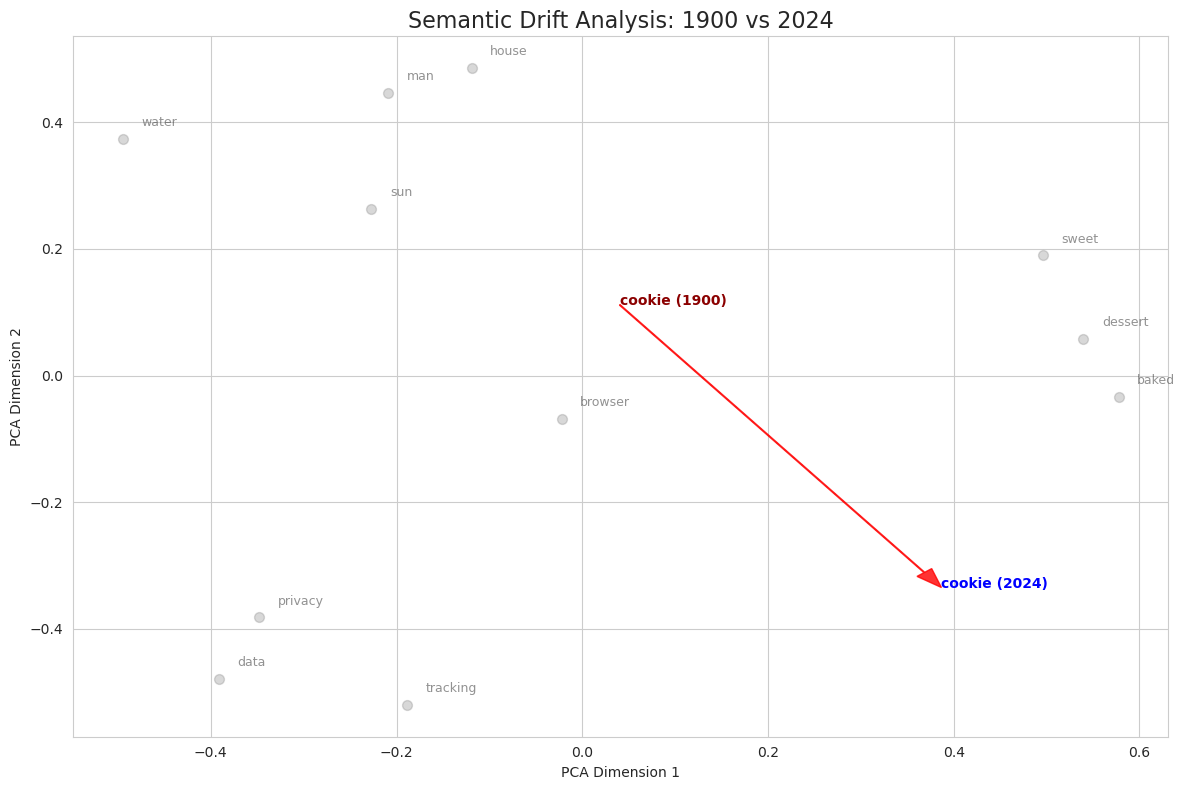

In [62]:
target_words = ["gay", "bullet", "cloud", "mouse", "troll", "cool", "sick", "wire", "stream", "cookie"]

anchors = {
    "gay": ["joyful", "carefree", "bright", "happy", "LGBTQ", "pride", "same-sex", "queer", "water", "sun", "man", "house"],
    "bullet": ["seed", "lead", "projectile", "firearm", "ammunition", "computer", "keyboard", "water", "sun", "man", "house"],
    "cloud": ["sky", "weather", "rain", "storage", "internet", "data", "server", "water", "sun", "man", "house"],
    "mouse": ["rodent", "animal", "cheese", "computer", "input", "device", "cursor", "water", "sun", "man", "house"],
    "troll": ["myth", "folklore", "creature", "internet", "harassment", "forum", "online", "water", "sun", "man", "house"],
    "cool": ["temperature", "chill", "cold", "fashionable", "impressive", "awesome", "trendy", "water", "sun", "man", "house"],
    "sick": ["ill", "disease", "unwell", "impressive", "awesome", "cool", "amazing", "water", "sun", "man", "house"],
    "wire": ["metal", "thread", "fence", "electricity", "communication", "transfer", "news", "water", "sun", "man", "house"],
    "stream": ["river", "water", "flow", "media", "video", "music", "online", "water", "sun", "man", "house"],
    "cookie": ["baked", "sweet", "dessert", "data", "browser", "tracking", "privacy", "water", "sun", "man", "house"]
}

# Plot for each target word
for target in target_words:
    plot_semantic_trajectory(mod_modern, mod_pg19, Rotation, [target], anchors[target])


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.linalg import orthogonal_procrustes

def visualize_embedding_drift(
    target_tokens: list, 
    context_tokens: list, 
    control_tokens: list, 
    old_model, 
    new_model, 
    dim_reducer: str = 'pca', 
    seed: int = 42
):
    """
    Automatically aligns two embedding models and plots the semantic drift of target words.
    
    Args:
        target_tokens: Words to visualize movement for (e.g., ['broadcast', 'monitor'])
        context_tokens: Words defining the semantic regions (e.g., ['farm', 'radio', 'screen'])
        control_tokens: Stable words to anchor the map (e.g., ['the', 'water', 'sun'])
        old_model: The PG-19 / Pre-tuned StaticModel
        new_model: The Modern / Base StaticModel
        dim_reducer: 'pca' (preserves direction) or 'tsne' (clusters better but distorts distance)
    """
    
    # --- 1. Internal Procrustes Alignment ---
    # We align the Old model onto the New model using the intersection of their vocabs
    print("Aligning models...")
    vocab_old = set(old_model.tokenizer.get_vocab().keys())
    vocab_new = set(new_model.tokenizer.get_vocab().keys())
    
    # Use top 2000 common words as anchors, filtering out short/rare noise
    common_vocab = sorted(list(vocab_old.intersection(vocab_new)))
    common_vocab = [w for w in common_vocab if len(w) > 3][:2000]
    
    A_base = new_model.encode(common_vocab)
    B_drift = old_model.encode(common_vocab)
    
    # Calculate Rotation Matrix R
    R, _ = orthogonal_procrustes(B_drift, A_base)
    
    # --- 2. Data Preparation ---
    # Filter inputs to ensure they exist in both models
    def filter_valid(words):
        valid = [w for w in words if w in vocab_old and w in vocab_new]
        missing = set(words) - set(valid)
        if missing: print(f"Warning: '{missing}' not found in vocabulary. Skipping.")
        return valid

    targets = filter_valid(target_tokens)
    contexts = filter_valid(context_tokens)
    controls = filter_valid(control_tokens)
    
    all_plot_words = list(set(targets + contexts + controls))
    
    # --- 3. Vector Extraction & Dimensionality Reduction ---
    # We define the "Space" using the New Model (Modern) vectors
    vectors_new = new_model.encode(all_plot_words)
    
    # Fit the reducer on the Modern Space
    if dim_reducer.lower() == 'tsne':
        reducer = TSNE(n_components=2, random_state=seed, perplexity=min(5, len(all_plot_words)-1))
    else:
        reducer = PCA(n_components=2, random_state=seed)
        
    coords_new = reducer.fit_transform(vectors_new)
    
    # Create a lookup for plotting
    word_to_coord = {w: coords_new[i] for i, w in enumerate(all_plot_words)}
    
    # --- 4. Plotting ---
    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")
    
    # A. Plot Stable Background (Controls & Context)
    # These represent the "Modern Map"
    x_bg, y_bg, labels_bg = [], [], []
    for w in contexts + controls:
        x_bg.append(word_to_coord[w][0])
        y_bg.append(word_to_coord[w][1])
        labels_bg.append(w)
        
    plt.scatter(x_bg, y_bg, c='lightgrey', s=100, alpha=0.6, label='Context Anchors')
    for i, txt in enumerate(labels_bg):
        plt.text(x_bg[i]+0.02, y_bg[i]+0.02, txt, fontsize=10, color='grey', alpha=0.8)
        
    # B. Plot Semantic Trajectories (Targets)
    print(f"Plotting trajectories for: {targets}")
    colors = plt.cm.rainbow(np.linspace(0, 1, len(targets)))
    
    for i, word in enumerate(targets):
        # 1. Get Old Vector & Align it
        vec_old_raw = old_model.encode([word])[0]
        vec_old_aligned = vec_old_raw @ R  # Apply Rotation
        
        # 2. Transform to 2D using the SAME reducer
        # Note: We must project the old vector into the established 2D space
        # For PCA this is valid using .transform(). For t-SNE it's tricky, 
        # so we approximate by re-embedding or (preferred) using PCA for drift.
        if dim_reducer == 'tsne':
             # t-SNE doesn't support .transform(), so we just plot the Destination
             # showing the drift via arrows is mathematically unstable in t-SNE.
             # We assume PCA for trajectories.
             print("Warning: Trajectories are approximate in t-SNE. Use PCA for accurate direction.")
             pos_start = word_to_coord[word] # Fallback to just point
        else:
             pos_start = reducer.transform([vec_old_aligned])[0]
        
        pos_end = word_to_coord[word]
        
        # 3. Draw Arrow
        plt.arrow(
            pos_start[0], pos_start[1], 
            pos_end[0] - pos_start[0], pos_end[1] - pos_start[1],
            color=colors[i], width=0.005, head_width=0.05, 
            length_includes_head=True, alpha=0.9
        )
        
        # 4. Labels
        plt.text(pos_start[0], pos_start[1], "1900", color=colors[i], fontsize=8, fontweight='bold')
        plt.text(pos_end[0], pos_end[1], word, color=colors[i], fontsize=12, fontweight='bold')

    plt.title(f"Semantic Drift: {dim_reducer.upper()} Projection", fontsize=16)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Aligning models...
Plotting trajectories for: []


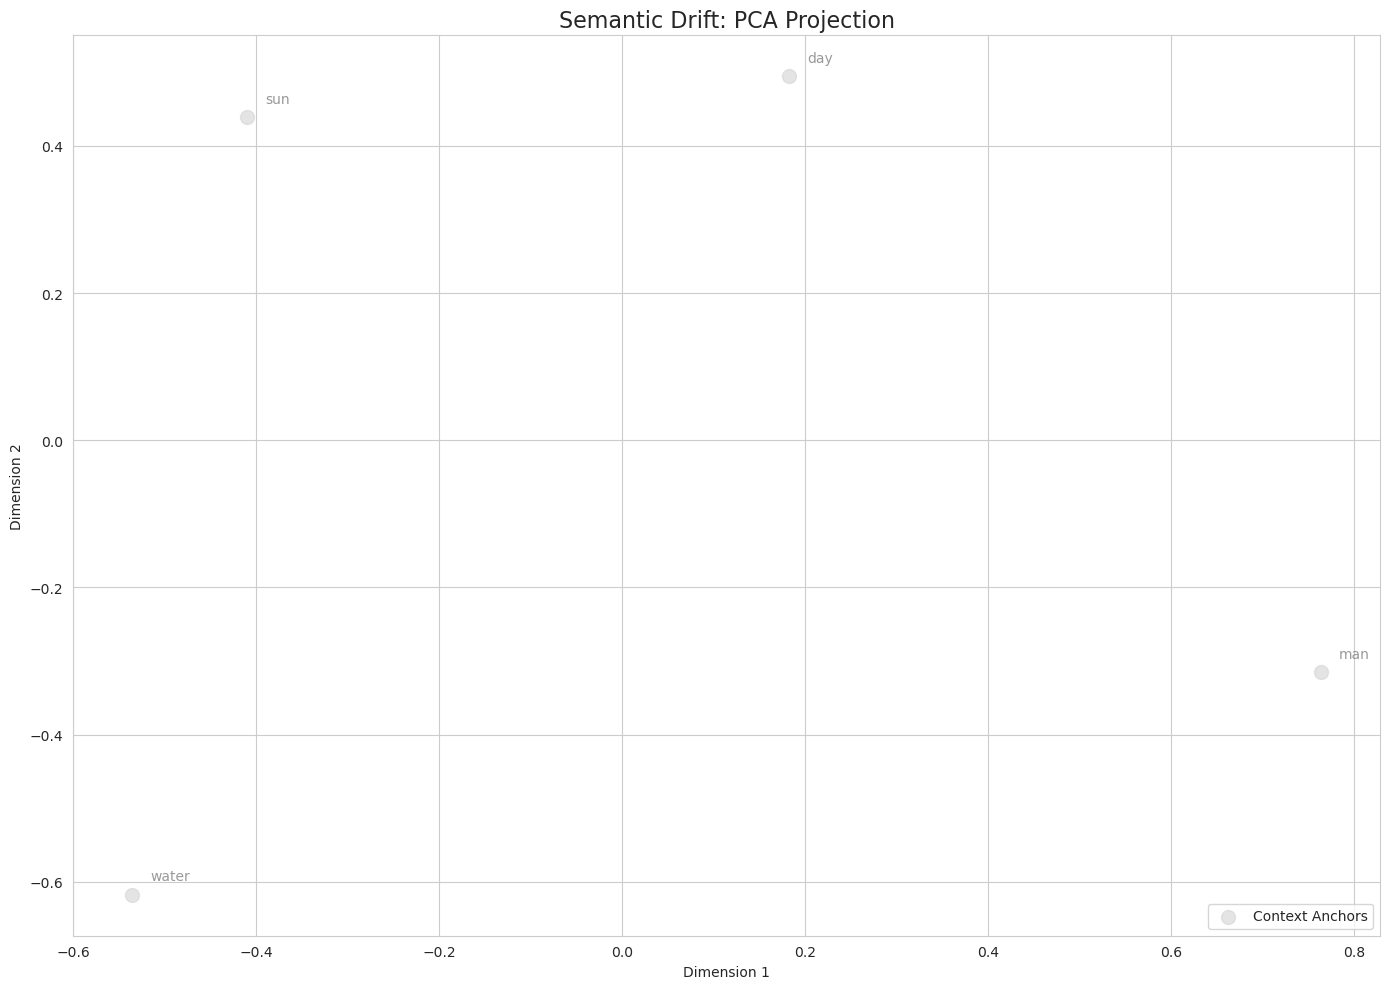

Aligning models...
Plotting trajectories for: []


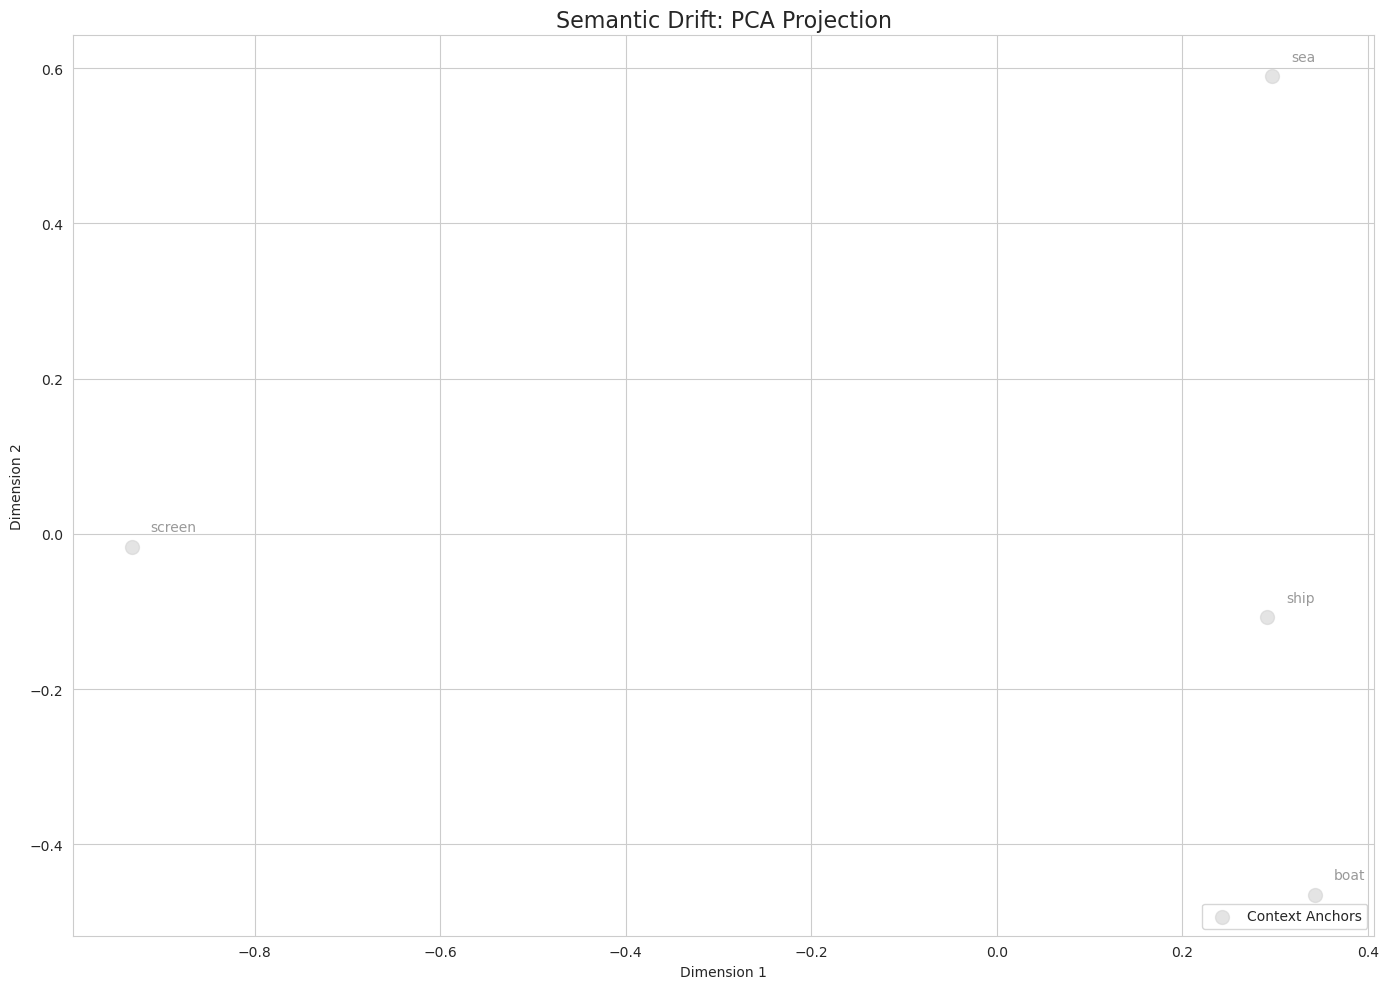

In [47]:
# Load your models
from model2vec import StaticModel
mod_modern = StaticModel.from_pretrained("minishlab/potion-base-8m")
mod_pg19 = StaticModel.from_pretrained("models/pg19_static_final")

# 1. Analyze "Broadcast" (Farm -> Tech)
visualize_embedding_drift(
    target_tokens=["broadcast"],
    context_tokens=["farm", "seed", "sow", "radio", "television", "signal"],
    control_tokens=["man", "day", "sun", "water"],
    old_model=mod_pg19,
    new_model=mod_modern
)

# 2. Analyze "Monitor" (Ship/Student -> Screen)
visualize_embedding_drift(
    target_tokens=["monitor"],
    context_tokens=["ship", "sea", "captain", "computer", "screen", "display"],
    control_tokens=["ocean", "steel", "boat"],
    old_model=mod_pg19,
    new_model=mod_modern
)